In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/psfc.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/t2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/SO2.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/NMVOC_finn.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/bio.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/rain.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/u10.npy
/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2/test_in/swdown.npy
/kaggle/input/competitions/anrf-aise-hack-pha

# where all input datasets are stored
os.listdir('/kaggle/input/')

In [4]:
# where all input datasets are stored
import os
os.listdir('/kaggle/input/')

['competitions']

In [5]:
# current working directory
os.getcwd()

'/kaggle/working'

raw date

In [6]:
import os

base = '/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd'

print(os.listdir(base))

['aisehack-theme-2']


In [7]:
print(os.listdir(os.path.join(base, 'aisehack-theme-2')))

['test_in', 'stats', 'raw']


In [8]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from statsmodels.tsa.seasonal import STL
from tqdm import tqdm
import torch.optim as optim

DATA_DIR = '/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2'
train_months = ['APRIL_16', 'JULY_16', 'OCT_16', 'DEC_16']
feature_list = ['cpm25', 'u10', 'v10', 'pblh', 't2', 'rain']
input_len = 10
output_len = 16

# Load raw data with memory mapping
train_raw = {m: {f: np.load(os.path.join(DATA_DIR, 'raw', m, f'{f}.npy'), mmap_mode='r') 
             for f in feature_list} for m in train_months}

In [9]:
import os

data_files = '/kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2'

# sanity check
if not os.path.exists(data_files):
    raise ValueError("Dataset path incorrect. Make sure you attached the competition dataset.")

print("Data path OK:", data_files)

Data path OK: /kaggle/input/competitions/anrf-aise-hack-phase-2-theme-2-pollution-forecasting-iitd/aisehack-theme-2


In [10]:
# ===== LOAD SINGLE MONTH DATA (APRIL) =====

data = {}

for feat in feature_list:
    path = os.path.join(data_files, 'raw', 'APRIL_16', f'{feat}.npy')
    
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    
    # use memory mapping (DO NOT cast here)
    data[feat] = np.load(path, mmap_mode='r')

# load time (small, safe to load fully)
time = np.load(os.path.join(data_files, 'raw', 'APRIL_16', 'time.npy'))

print("Loaded features:", list(data.keys()))

Loaded features: ['cpm25', 'u10', 'v10', 'pblh', 't2', 'rain']


In [11]:
# Load time
time = np.load(os.path.join(data_files, 'raw', 'APRIL_16', 'time.npy'))

# Print time range
print("Start time:", time[0])
print("End time:", time[-1])

# Check shapes of selected features only
for feat in feature_list:
    print(f"{feat} shape:", data[feat].shape)

# Confirm all shapes match
shapes = [data[feat].shape for feat in feature_list]
print("\nAll shapes same:", len(set(shapes)) == 1)

# Interpretation
print("\nShape format: (time, latitude, longitude)")
print("Each timestep = 140x124 spatial grid")

Start time: 2016-04-01T00:00:00
End time: 2016-04-30T18:00:00
cpm25 shape: (715, 140, 124)
u10 shape: (715, 140, 124)
v10 shape: (715, 140, 124)
pblh shape: (715, 140, 124)
t2 shape: (715, 140, 124)
rain shape: (715, 140, 124)

All shapes same: True

Shape format: (time, latitude, longitude)
Each timestep = 140x124 spatial grid


MAPS****

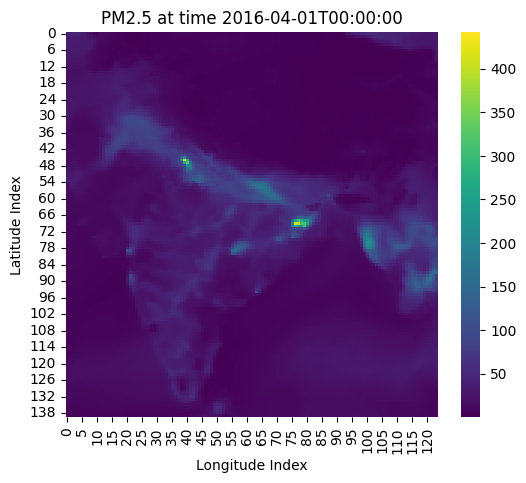

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select timestep
t = 0

# Plot PM2.5 heatmap
plt.figure(figsize=(6,5))
sns.heatmap(data['cpm25'][t, ::-1, :], cmap='viridis')
plt.title(f"PM2.5 at time {time[t]}")
plt.xlabel("Longitude Index")
plt.ylabel("Latitude Index")
plt.show()

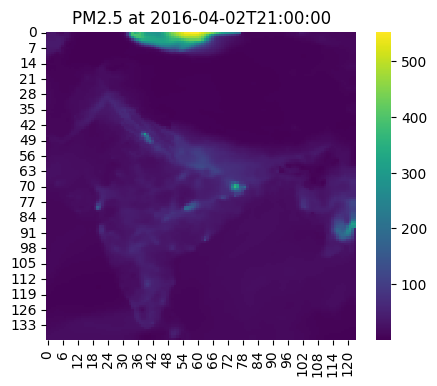

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

t = 45
plt.figure(figsize=(5,4))
sns.heatmap(data['cpm25'][t, ::-1, :], cmap='viridis')
plt.title(f"PM2.5 at {time[t]}")
plt.show()

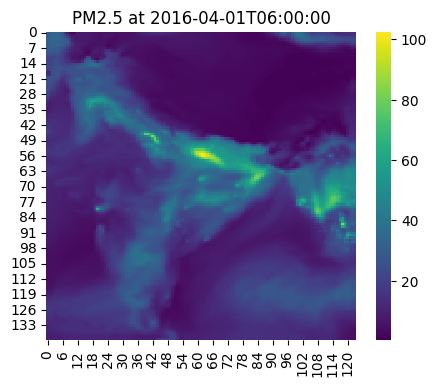

In [14]:
t = 6
plt.figure(figsize=(5,4))
sns.heatmap(data['cpm25'][t, ::-1, :], cmap='viridis')
plt.title(f"PM2.5 at {time[t]}")
plt.show()

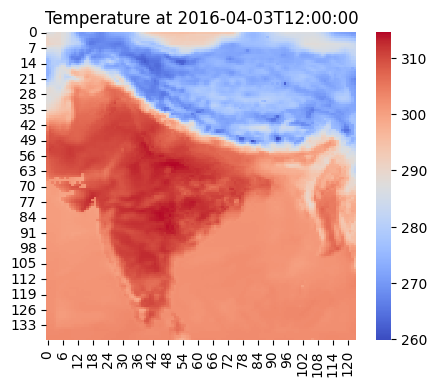

In [15]:
t = 60
plt.figure(figsize=(5,4))
sns.heatmap(data['t2'][t, ::-1, :], cmap='coolwarm')
plt.title(f"Temperature at {time[t]}")
plt.show()

EP DETECTION

In [16]:
from joblib import Parallel, delayed
import os

# 1. Define and create the directory (Fixes the NameError)
save_dir = '/kaggle/working/episode_masks'
os.makedirs(save_dir, exist_ok=True)

def process_pixel(ts):
    res = STL(ts, period=24, robust=True).fit()
    remainder = res.resid
    std_val = np.std(remainder) + 1e-8
    return ((remainder > 3 * std_val) & (ts > 1)).astype(np.uint8)

for month in train_months:
    cpm = np.array(train_raw[month]['cpm25'], dtype=np.float32)
    T, H, W = cpm.shape
    data_2d = cpm.reshape(T, -1)
    
    # Parallel processing using all 4 CPU cores
    results = Parallel(n_jobs=-1)(
        delayed(process_pixel)(data_2d[:, k]) 
        for k in tqdm(range(data_2d.shape[1]), desc=f"Parallel STL: {month}")
    )
    
    mask_2d = np.array(results).T
    np.save(os.path.join(save_dir, f'{month}_mask.npy'), mask_2d.reshape(T, H, W))

print("All episode masks generated and saved!")

Parallel STL: APRIL_16: 100%|██████████| 17360/17360 [11:27<00:00, 25.25it/s]


NameError: name 'save_dir' is not defined

In [ ]:
episode_masks = {}

for month in train_months:
    path = f'/kaggle/working/episode_masks/{month}_mask.npy'
    episode_masks[month] = np.load(path, mmap_mode='r')

print("Episode masks loaded.")

NORMALIZE 

In [ ]:
stats = {}
for feat in feature_list:
    total_sum, total_sq, total_n = 0.0, 0.0, 0
    for m in train_months:
        arr = np.array(train_raw[m][feat], dtype=np.float64)
        total_sum += arr.sum()
        total_sq += (arr ** 2).sum()
        total_n += arr.size
    mean = total_sum / total_n
    std = np.sqrt(max(total_sq / total_n - mean**2, 1e-8))
    stats[feat] = {'mean': mean, 'std': std}

class PMDataset(Dataset):
    def __init__(self, raw, masks, indices):
        self.raw, self.masks, self.indices = raw, masks, indices

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        m, s = self.indices[i]
        x_feats = []
        for f in feature_list:
            arr = (np.array(self.raw[m][f][s:s+input_len], dtype=np.float32) - stats[f]['mean']) / stats[f]['std']
            x_feats.append(arr)
        
        X = np.stack(x_feats, axis=-1) # (T_in, H, W, F)
        Y = (np.array(self.raw[m]['cpm25'][s+input_len:s+input_len+output_len], dtype=np.float32) - stats['cpm25']['mean']) / stats['cpm25']['std']
        M = np.array(self.masks[m][s+input_len:s+input_len+output_len], dtype=np.float32)
        return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(M)

# Build Indices
train_idx, val_idx = [], []
for m in train_months:
    T = train_raw[m]['cpm25'].shape[0]
    starts = list(range(0, T - (input_len + output_len) + 1))
    split = int(0.8 * len(starts))
    train_idx += [(m, s) for s in starts[:split]]; val_idx += [(m, s) for s in starts[split:]]

train_loader = DataLoader(PMDataset(train_raw, episode_masks, train_idx), batch_size=4, shuffle=True) # Increased batch for T4
val_loader = DataLoader(PMDataset(train_raw, episode_masks, val_idx), batch_size=4)

MAKE TRAIN/VAL

In [ ]:
# ===== GLOBAL CONFIG (RUN BEFORE SAMPLE CREATION) =====

input_len = 10
output_len = 16
stride = 1

print("input_len:", input_len)
print("output_len:", output_len)
print("stride:", stride)

In [ ]:
def build_indices(months):
    train_idx, val_idx = [], []

    for m in months:
        T = train_raw[m]['cpm25'].shape[0]
        # Calculate total possible windows
        starts = list(range(0, T - (input_len + output_len) + 1))

        # 80/20 Split
        split = int(0.8 * len(starts))
        train_idx += [(m, s) for s in starts[:split]]
        val_idx += [(m, s) for s in starts[split:]]

    return train_idx, val_idx

train_indices, val_indices = build_indices(train_months)
print(f"Total Training Samples: {len(train_indices)} | Validation: {len(val_indices)}")

DATA LOADER 

In [ ]:
class PMDataset(Dataset):
    def __init__(self, raw, masks, indices):
        self.raw = raw
        self.masks = masks
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        m, s = self.indices[i]

        # 1. Input Features: Shape (10, 140, 124, 6)
        x_list = []
        for f in feature_list:
            # Extract 10 steps, cast to float32, and normalize
            arr = np.array(self.raw[m][f][s : s + input_len], dtype=np.float32)
            arr = (arr - stats[f]['mean']) / stats[f]['std']
            x_list.append(arr)
        
        # Stack on the LAST dimension to get (Time, H, W, Features)
        X = np.stack(x_list, axis=-1)

        # 2. Target CPM25: Shape (16, 140, 124)
        Y = np.array(self.raw[m]['cpm25'][s + input_len : s + input_len + output_len], dtype=np.float32)
        Y = (Y - stats['cpm25']['mean']) / stats['cpm25']['std']

        # 3. Episode Mask: Shape (16, 140, 124)
        M = np.array(self.masks[m][s + input_len : s + input_len + output_len], dtype=np.float32)

        return torch.from_numpy(X), torch.from_numpy(Y), torch.from_numpy(M)

# Batch size 4 is ideal for T4 GPU with this model size
train_loader = DataLoader(PMDataset(train_raw, episode_masks, train_indices), batch_size=4, shuffle=True)
val_loader   = DataLoader(PMDataset(train_raw, episode_masks, val_indices), batch_size=4, shuffle=False)

# Verification check
sample_x, sample_y, sample_m = next(iter(train_loader))
print(f"Loader Check - X: {sample_x.shape}, Y: {sample_y.shape}") 
# Expected: torch.Size([4, 10, 140, 124, 6]), torch.Size([4, 16, 140, 124])

LOAD TEST INPUTS 

In [ ]:
test_raw = {}
test_in_dir = os.path.join(DATA_DIR, 'test_in')

for f in feature_list:
    path = os.path.join(test_in_dir, f'{f}.npy')
    # Use memory mapping to keep the Kaggle kernel from crashing
    test_raw[f] = np.load(path, mmap_mode='r')
    print(f"Test Input {f}:", test_raw[f].shape) 
    # Should be (218, 10, 140, 124)

MODEL

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1 / (in_channels * out_channels)
        # T4 prefers complex64 for FFT operations
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def forward(self, x):
        batchsize = x.shape[0]
        # Real-to-Complex FFT
        x_ft = torch.fft.rfft2(x)

        # Output buffer on device
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, 
                             dtype=torch.cfloat, device=x.device)

        # Multiply relevant Fourier modes
        out_ft[:, :, :self.modes1, :self.modes2] = torch.einsum("bixy,ioxy->boxy", 
                                                                x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = torch.einsum("bixy,ioxy->boxy", 
                                                                 x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        # Complex-to-Real Inverse FFT
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNO2d(nn.Module):
    def __init__(self, in_channels, out_channels=16, width=64, modes1=12, modes2=12):
        super().__init__()
        # in_channels + 2 for the (x, y) grid coordinates
        self.fc0 = nn.Conv2d(in_channels + 2, width, 1) 

        self.convs = nn.ModuleList([SpectralConv2d(width, width, modes1, modes2) for _ in range(4)])
        self.ws = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(4)])

        self.fc1 = nn.Conv2d(width, 128, 1)
        self.fc2 = nn.Conv2d(128, out_channels, 1)

    def forward(self, x):
        # x shape: (B, T, H, W, F) -> needs to be (B, C, H, W)
        B, T, H, W, Fch = x.shape
        x = x.permute(0, 1, 4, 2, 3).reshape(B, T*Fch, H, W)

        # Add spatial grid
        gridx = torch.linspace(0, 1, H, device=x.device).view(1, 1, H, 1).repeat(B, 1, 1, W)
        gridy = torch.linspace(0, 1, W, device=x.device).view(1, 1, 1, W).repeat(B, 1, H, 1)
        x = torch.cat([x, gridx, gridy], dim=1)

        x = self.fc0(x)
        for i in range(4):
            x1 = self.convs[i](x)
            x2 = self.ws[i](x)
            x = F.gelu(x1 + x2)

        x = self.fc2(F.gelu(self.fc1(x)))
        return x # (B, 16, H, W)

In [ ]:
def weighted_mse(pred, target, mask, alpha=5.0):
    w = 1 + alpha * mask
    return ((pred - target)**2 * w).mean()

TRAINING LOOP

In [ ]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FNO2d(in_channels=input_len * len(feature_list)).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

def weighted_mse(pred, target, mask):
    # Heavily weight the 'episodes' identified by your mask
    weight = 1.0 + (mask * 5.0) 
    return (weight * (pred - target)**2).mean()

for epoch in range(5):
    model.train()
    epoch_loss = 0
    
    for xb, yb, mb in tqdm(train_loader):
        # T4 Tip: Ensure float32 for best performance/compatibility
        xb, yb, mb = xb.to(device).float(), yb.to(device).float(), mb.to(device).float()

        optimizer.zero_grad()
        pred = model(xb)
        loss = weighted_mse(pred, yb, mb)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(train_loader):.6f}")
    torch.cuda.empty_cache() # Keeps T4 memory clean
    # Save the 'brain' of the model
    torch.save(model.state_dict(), '/kaggle/working/fno_model_v1.pth')
# Save the stats so your normalization is consistent
    np.save('/kaggle/working/stats.npy', stats) 
    print("Model and Stats saved!")

INFERENCE 

In [ ]:
model.eval()
all_test_preds = []

with torch.no_grad():
    # Loop through all 218 test samples
    num_samples = test_raw['cpm25'].shape[0] 
    
    for i in tqdm(range(num_samples), desc="Generating Submissions"):
        x_sample = []
        torch.cuda.empty_cache()
        for f in feature_list:
            # Normalize: (10, 140, 124)
            val = (np.array(test_raw[f][i], dtype=np.float32) - stats[f]['mean']) / stats[f]['std']
            x_sample.append(val)
        
        # Stack features: (10, 140, 124, 6) -> Add batch: (1, 10, 140, 124, 6)
        X_batch = torch.from_numpy(np.stack(x_sample, axis=-1)).unsqueeze(0).to(device).float()
        
        # FNO Forward Pass -> (1, 16, 140, 124)
        pred = model(X_batch)
        
        # Move to CPU and remove batch dim -> (16, 140, 124)
        pred = pred.squeeze(0).cpu().numpy()
        
        # Denormalize CPM25 values
        pred = (pred * stats['cpm25']['std']) + stats['cpm25']['mean']
        
        # CRITICAL STEP: Reorder dims from (Time, H, W) to (H, W, Time)
        # This results in (140, 124, 16)
        pred_final = pred.transpose(1, 2, 0)
        
        all_test_preds.append(pred_final)

# Combine all 218 samples into the final array
final_submission = np.stack(all_test_preds) 

# Verification Print
print(f"Final Array Shape: {final_submission.shape}") 
# Should strictly print: (218, 140, 124, 16)

# Save as float32 to save space while maintaining precision
np.save('/kaggle/working/preds.npy', final_submission.astype(np.float32))